# Segmentación Avanzada de Clientes – Mall Customers

Notebook extendido que incorpora:
- Perfilado automático por cluster
- Inclusión de Age y Genre como validación externa
- Modelo predictivo de asignación de clusters
- Comparación con segmentación RFM simulada
- Versión lista para dashboard interactivo (Streamlit)

**No incluye exportación a Excel ni PDF**, según lo solicitado.

## 1. Carga de librerías y datos

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


In [30]:

df = pd.read_csv('Mall_Customers.csv')
df.head(10)

# transformar campo 'genre' a variable numérica
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})


X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X_scaled = StandardScaler().fit_transform(X)

## 2. Clusterización Jerárquica (Base)

Text(0, 0.5, 'Silhouette')

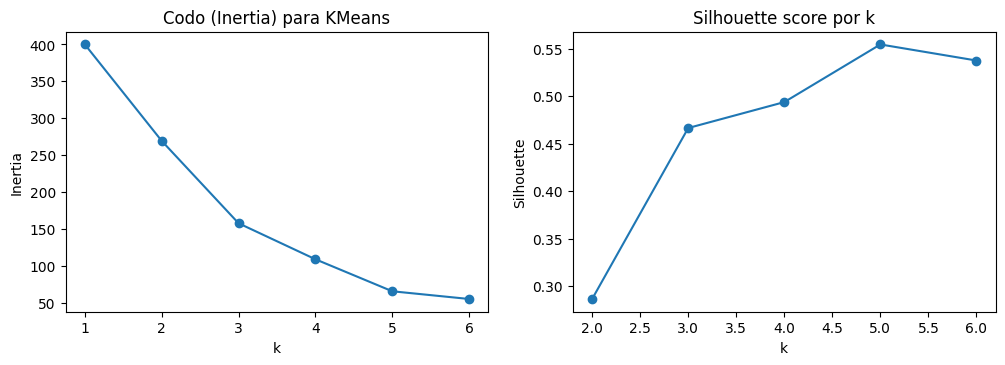

In [31]:
# Determinar k con el método del codo (elbow) y calcular silhouette para k>=2
inertias = []
sil_scores = []

# Probar k de 1 a 6 con kmeans
ks = range(1, 7)
for k in ks:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    if k >= 2:
        sil_scores.append(silhouette_score(X_scaled, km.labels_))
    else:
        sil_scores.append(np.nan)

# Elegir k=5 (conocimiento previo del dataset) y ajustar KMeans
k_opt = 5
kmeans = KMeans(n_clusters=k_opt, random_state=0, n_init=10).fit(X_scaled)
labels_km = kmeans.labels_

# Score de silhouette
sil = silhouette_score(X_scaled, labels_km)

# Visualizaciones
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(ks, inertias, '-o')
plt.title('Codo (Inertia) para KMeans')
plt.xlabel('k')
plt.ylabel('Inertia')

plt.subplot(2, 2, 2)
plt.plot(ks, sil_scores, '-o')
plt.title('Silhouette score por k')
plt.xlabel('k')
plt.ylabel('Silhouette')

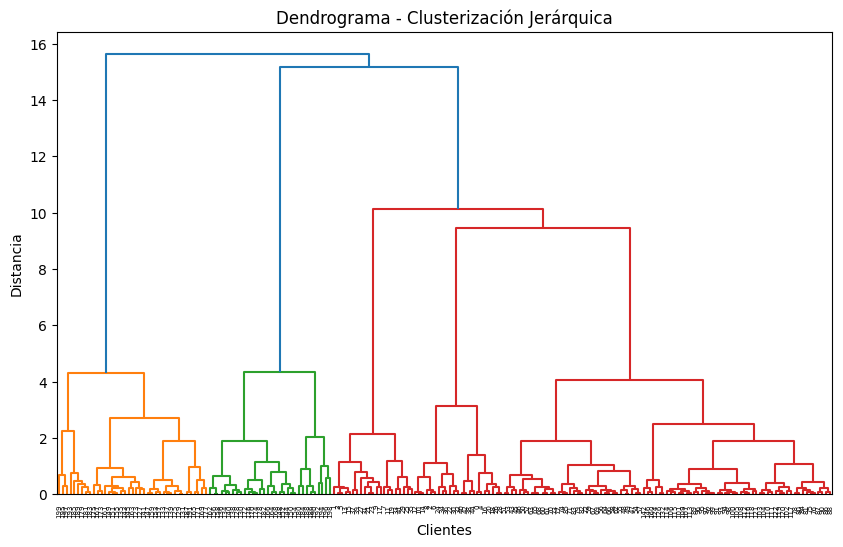

In [32]:
# Dendrograma para clusterización jerárquica
Z = linkage(X_scaled, method='ward')
df['Cluster'] = fcluster(Z, t=5, criterion='maxclust')

plt.figure(figsize=(10,6))
dendrogram(Z)
plt.title("Dendrograma - Clusterización Jerárquica")
plt.xlabel("Clientes")
plt.ylabel("Distancia")
plt.show()

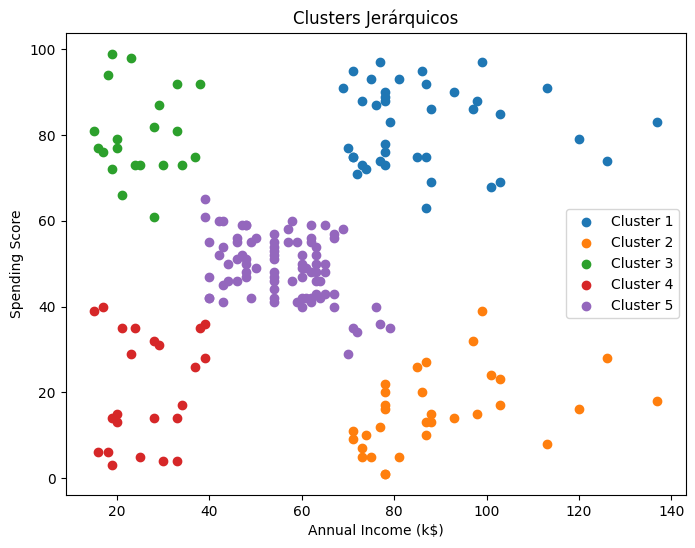

In [33]:
# Visualización de los clusters
plt.figure(figsize=(8,6))
for c in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['Annual Income (k$)'], subset['Spending Score (1-100)'], label=f'Cluster {c}')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Clusters Jerárquicos")
plt.legend()
plt.show()

## 3. Perfilado automático de clusters

In [34]:

profile = df.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'N_Clientes'})

profile


,Age,Annual Income (k$),Spending Score (1-100),N_Clientes
Cluster,,,,
1,32.692308,86.538462,82.128205,39
2,41.000000,89.406250,15.593750,32
3,25.333333,25.095238,80.047619,21
4,45.217391,26.304348,20.913043,23
5,42.482353,55.811765,49.129412,85


## 4. Validación externa con Age y Genre

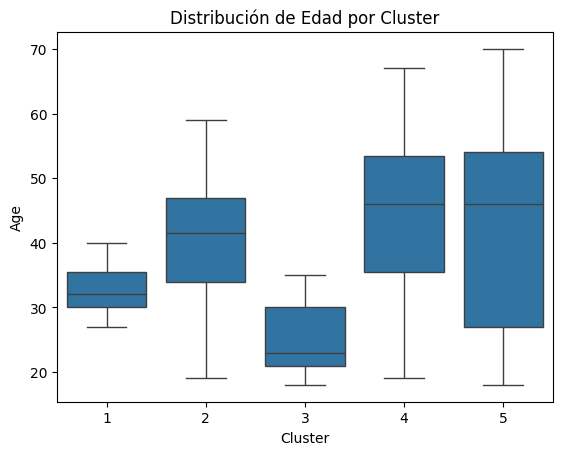

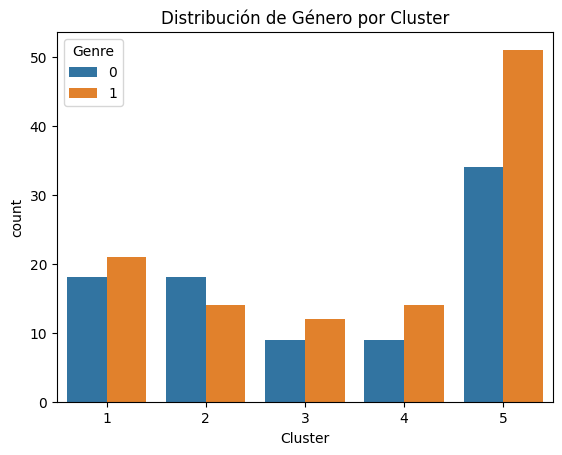

In [44]:

sns.boxplot(data=df, x='Cluster', y='Age')
plt.title("Distribución de Edad por Cluster")
plt.show()

sns.countplot(data=df, x='Cluster', hue='Genre')
plt.title("Distribución de Género por Cluster")
plt.show()


## 5. Comparación con K-Means

In [36]:

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster_KM'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster_KM')[['Annual Income (k$)', 'Spending Score (1-100)']].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster_KM,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## 6. Modelo predictivo para nuevos clientes

In [47]:

features = df[['Age', 'Genre', 'Annual Income (k$)', 'Spending Score (1-100)']]
X_model = StandardScaler().fit_transform(features)
y = df['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           1       1.00      1.00      1.00        10
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         6
           5       0.95      1.00      0.98        21

    accuracy                           0.98        50
   macro avg       0.99      0.97      0.98        50
weighted avg       0.98      0.98      0.98        50



## 7. Importancia de variables

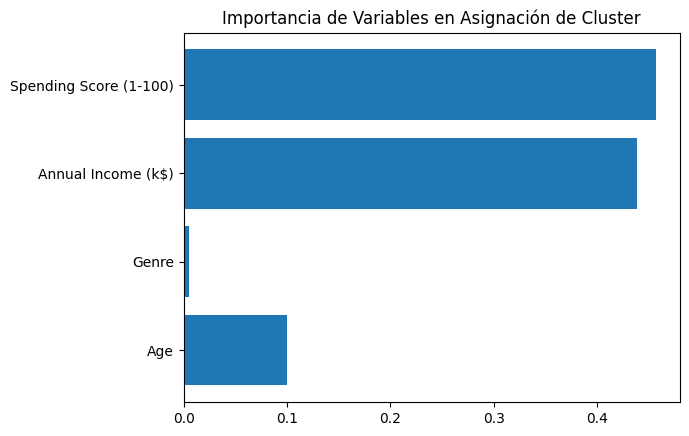

In [48]:

importances = model.feature_importances_
plt.barh(features.columns, importances)
plt.title("Importancia de Variables en Asignación de Cluster")
plt.show()


## 8. Genera predicciones para nuevos clientes

In [ ]:
# generar predicciones de cluster para nuevos datos
new_data = pd.DataFrame({
    'Age': [25, 40],
    'Genre': [0, 1],
    'Annual Income (k$)': [50, 80],
    'Spending Score (1-100)': [60, 30]
})
new_data_scaled = StandardScaler().fit_transform(new_data)
predicted_clusters = model.predict(new_data_scaled)
predicted_clusters
# define el cluster para cada new_data

predicted_clusters = model.predict(new_data_scaled)
new_data['Cluster'] = predicted_clusters
print(new_data)

   Age  Genre  Annual Income (k$)  Spending Score (1-100)  Cluster
0   25      0                  50                      60        3
1   40      1                  80                      30        2
